In [15]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END

In [16]:
class AgentState(TypedDict):
    num1:int
    num2:int
    final1:str
    operation1:str
    num3:int
    num4:int
    operation2:str
    final2:str

In [17]:
def adder1(state:AgentState)->AgentState:
    """This function adds two no.s"""
    state["final1"]=state["num1"]+state["num2"]
    return state


def subtractor1(state:AgentState)->AgentState:
    """This function subtracts two no.s"""
    state["final1"]=state["num1"]-state["num2"]
    return state


def adder2(state:AgentState)->AgentState:
    """This function adds two no.s"""
    state["final2"]=state["num3"]+state["num4"]
    return state


def subtractor2(state:AgentState)->AgentState:
    """This function subtracts two no.s"""
    state["final2"]=state["num3"]-state["num4"]
    return state


def decision_maker1(state:AgentState)->AgentState:
    if(state["operation1"]=='+'):
        return "addition_operator1"
    
    else:
        return "subtraction_operator1"
    
def decision_maker2(state:AgentState)->AgentState:
    if(state["operation2"]=='+'):
        return "addition_operator2"
    
    else:
        return "subtraction_operator2"

In [18]:
graph=StateGraph(AgentState)
graph.add_node("add_func1",adder1)
graph.add_node("subtract_func1",subtractor1)
graph.add_node("router1",lambda state:state)
graph.add_edge(START,"router1")
graph.add_conditional_edges(
    "router1",
    decision_maker1,
    {
        "addition_operator1":"add_func1",
        "subtraction_operator1":"subtract_func1"
    }
)
graph.add_edge("add_func1","router2")
graph.add_edge("subtract_func1","router2")


graph.add_node("add_func2",adder2)
graph.add_node("subtract_func2",subtractor2)
graph.add_node("router2",lambda state:state)

graph.add_conditional_edges(
    "router2",
    decision_maker2,
    {
        "addition_operator2":"add_func2",
        "subtraction_operator2":"subtract_func2"
    }
)

graph.add_edge("add_func2",END)
graph.add_edge("subtract_func2",END)


app=graph.compile()






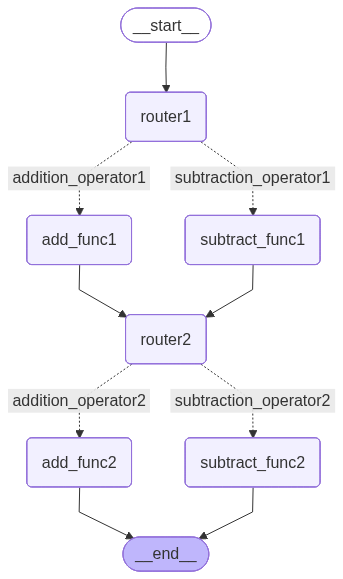

In [ ]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
Sample_input=AgentState({"num1":390,"num2":99,"operation1":"-","num3":980,"num4":788,"operation2":"+"})
print(app.invoke(Sample_input))

{'num1': 390, 'num2': 99, 'final1': 291, 'operation1': '-', 'num3': 980, 'num4': 788, 'operation2': '+', 'final2': 1768}
